# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is called “linear” because it is linear in the parameters (the coefficients), not necessarily in the variables. This means the model is a linear combination of the coefficients, even if the variables themselves are transformed (like squared or interacted).
2. The intercept is the baseline group, and each dummy coefficient shows the difference from that group. So the coefficient tells you how much higher or lower that category is compared to the baseline.
3. Linear regression can be used for classification by predicting values and then applying a threshold (like 0.5), but it’s not ideal. The main issue is that linear regression can produce predictions outside the 0 to 1 range, which doesn’t necessarily make sense for probabilities. It also doesn’t model the relationship properly when the outcome is binary.
4. Overfitting shows up when the model does well on training data but poorly on test data. It also happens when adding complexity improves fit but not prediction, and when coefficients become unstable.
5. Multicolinearity happens when two or more explanatory variables are highly correlated, which makes it hard to separate their individual effects on the outcome. This leads to unstable and imprecise coefficient estimates. In two-stage least squares, we deal with this by replacing the problematic variable with a predicted version that comes from instruments. In the first stage, we regress the correlated variable on instruments that are related to it but not directly to the outcome. In the second stage, we use the predicted values instead of the original variable in the regression. This helps reduce the issues caused by multicollinearity, since the predicted variable is less correlated with the other regressors and isolates the variation we care about.
6. Nonlinear relationships can be captured by adding polynomial terms, interactions, or transformations like logs. This allows the model to fit curves instead of just straight lines while still using linear regression.
7. The slope coefficient represents the change in the outcome variable for a one-unit increase in the independent variable, holding all other variables constant. It shows the marginal effect of that variable on the outcome.
8. Train/test split uses one split and is faster but less stable, while k-fold cross validation uses multiple splits and gives a more reliable estimate of performance.
9. k is usually set to 5 or 10, since it balances accuracy and computation time. Larger
k gives more precise results but is more expensive to run.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                avg_price  avg_rating
neighbourhood                        
Manhattan      183.664286   91.801496
Staten Island  146.166667   90.843750
Brooklyn       127.747378   92.363497
Queens          96.857233   91.549057
Bronx           75.276498   91.654378


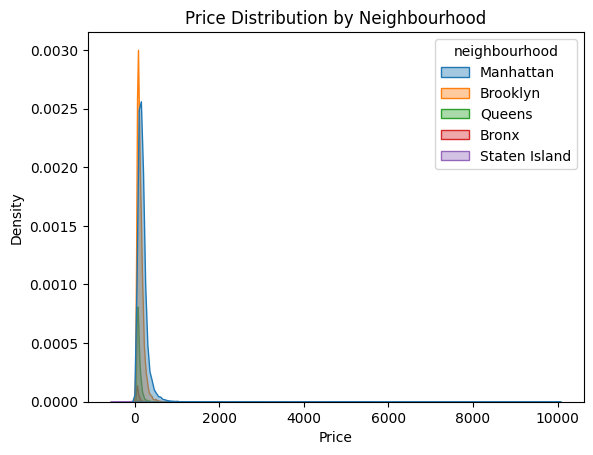

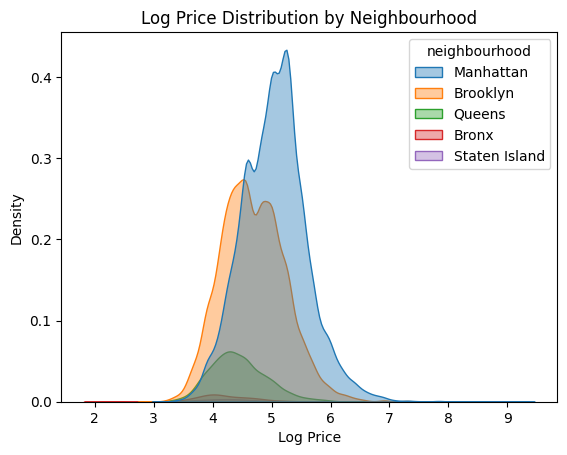

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
df = pd.read_csv("./undergrad_ml_assignments/data/Q1_clean.csv")
df = df.rename(columns={
    "Price per night": "price",
    "Review Scores Rating": "rating",
    "Neighbourhood ": "neighbourhood"
})
df.columns = df.columns.str.strip().str.lower()
summary = df.groupby("neighbourhood").agg(
    avg_price=("price", "mean"),
    avg_rating=("rating", "mean")
).sort_values("avg_price", ascending=False)
print(summary)
sns.kdeplot(data=df, x="price", hue="neighbourhood", fill=True, alpha=0.4)
plt.title("Price Distribution by Neighbourhood")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()
df["log_price"] = np.log(df["price"])
sns.kdeplot(data=df, x="log_price", hue="neighbourhood", fill=True, alpha=0.4)
plt.title("Log Price Distribution by Neighbourhood")
plt.xlabel("Log Price")
plt.ylabel("Density")
plt.show()

1. Manhattan is the most expensive on average.

In [19]:
import statsmodels.formula.api as smf
model1 = smf.ols("price ~ C(neighbourhood)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        18:25:40   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

2. In this regression, Bronx is the baseline category, so the intercept represents the average price in the Bronx. The coefficients for the other neighbourhoods show how much higher their average prices are compared to the Bronx. When you add the intercept to each coefficient, you get the exact average prices from the table in part 1. So basically, the regression is just another way of representing the group averages, but in terms of differences from the baseline.

In [20]:
model2 = smf.ols("price ~ rating", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        18:26:35   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.8784     10.423      5.841      0.0

3. The slope coefficient on rating is about 1.02, which means that for every one-point increase in the review score, the price per night increases by about $1 on average. So higher-rated properties tend to be slightly more expensive, but the effect is pretty small.

In [21]:
model3 = smf.ols("price ~ C(neighbourhood) + rating", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        18:27:14   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

4. The rating coefficient increases slightly from about 1.02 to 1.08 after adding neighbourhood, showing that the effect of rating is a bit stronger once we control for location. The neighbourhood coefficients remain similar, but now they represent price differences holding rating constant instead of simple average differences.

In [22]:
model4 = smf.ols("price ~ rating * C(neighbourhood)", data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:27:50   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

5. The slopes are mostly similar across neighbourhoods. The interaction terms for Brooklyn, Manhattan, and Queens are small and not statistically significant, which suggests that the effect of rating on price is pretty consistent in those areas. However, Staten Island is very different, with a large and significant negative interaction, meaning the relationship between rating and price there is not the same. So overall, the slopes are similar for most neighbourhoods, except for Staten Island which stands out.

In [23]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import statsmodels.formula.api as smf

def cross_val_mse(formula, df, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    mses = []

    for train_idx, test_idx in kf.split(df):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        model = smf.ols(formula, data=train).fit()
        preds = model.predict(test)

        mse = mean_squared_error(test["price"], preds)
        mses.append(mse)

    return np.mean(mses)

# Run CV for each model
mse_model4 = cross_val_mse("price ~ rating", df)
mse_model5 = cross_val_mse("price ~ C(neighbourhood) + rating", df)
mse_model6 = cross_val_mse("price ~ rating * C(neighbourhood)", df)

print("Model 4 (rating):", mse_model4)
print("Model 5 (neighbourhood + rating):", mse_model5)
print("Model 6 (interaction):", mse_model6)

Model 4 (rating): 22078.215444464753
Model 5 (neighbourhood + rating): 21068.500019790663
Model 6 (interaction): 21293.76899859329


6. Model 5 has the lowest MSE, so it performs the best. Adding neighbourhood clearly improves the model compared to using rating alone, while the interaction model does not add much value and slightly worsens performance.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: price, dtype: float64


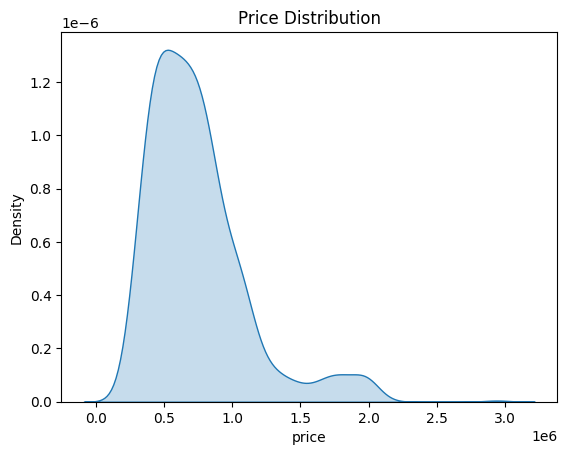

           count          mean            std       min       25%        50%  \
body_type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
body_type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


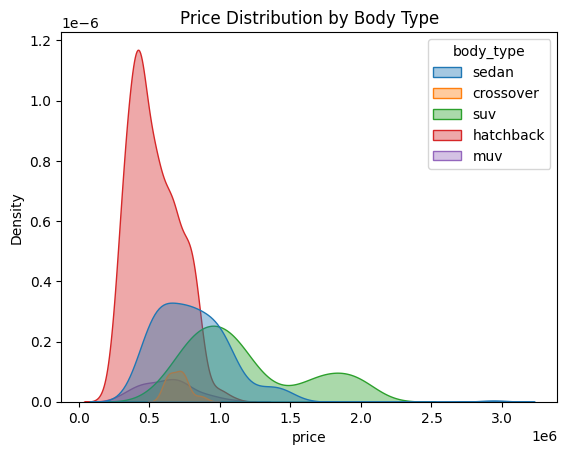

In [27]:
df2 = pd.read_csv("./undergrad_ml_assignments/data/cars_hw.csv")
df2.columns = df2.columns.str.strip().str.lower()
print(df2["price"].describe())
sns.kdeplot(data=df2, x="price", fill=True)
plt.title("Price Distribution")
plt.show()
group_summary = df2.groupby("body_type")["price"].describe()
print(group_summary)
sns.kdeplot(data=df2, x="price", hue="body_type", fill=True, alpha=0.4)
plt.title("Price Distribution by Body Type")
plt.show()

1. Crossover is the most expensive car type, with SUVs having the most variance.

In [29]:
model_seat = smf.ols("price ~ seating_capacity", data=df2).fit()
print(model_seat.summary())
model_cat = smf.ols("price ~ C(seating_capacity)", data=df2).fit()
print(model_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        18:40:26   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

2. The slope is about 59,270, meaning each extra seat is associated with roughly a $59,000 increase in price on average. This suggests that cars with more seats are generally more expensive. The differences are not roughly linear, since the increases in price between seating categories are uneven. Some categories show much larger jumps than others, so treating seating capacity as categorical gives a better fit than assuming a constant increase per seat.

In [31]:
df2["age"] = 2026 - df2["make_year"]
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import statsmodels.api as sm

def cross_val_poly(degree, df, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    mses = []
    for train_idx, test_idx in kf.split(df):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]
        X_train = np.column_stack([train["age"]**d for d in range(1, degree+1)])
        X_test = np.column_stack([test["age"]**d for d in range(1, degree+1)])
        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test)
        model = sm.OLS(train["price"], X_train).fit()
        preds = model.predict(X_test)
        mse = mean_squared_error(test["price"], preds)
        mses.append(mse)
    return np.mean(mses)
for d in range(1, 5):
    print(f"Degree {d}:", cross_val_poly(d, df2))

Degree 1: 97745760011.44072
Degree 2: 97815319552.31638
Degree 3: 97304076284.38248
Degree 4: 96785385468.59647


3. The degree 4 model has the lowest MSE, so it is the optimal choice. This suggests that the relationship between age and price is nonlinear and requires higher-order terms to capture it properly.

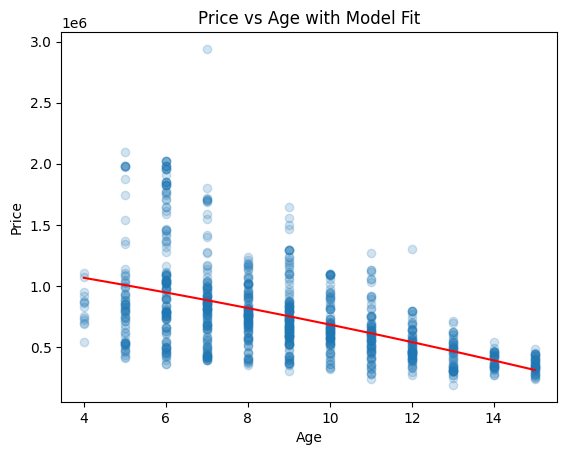

In [33]:
df2["age2"] = df2["age"]**2
model_poly = smf.ols("price ~ age + age2", data=df2).fit()
df_sorted = df2.sort_values("age")
df_sorted["pred_price"] = model_poly.predict(df_sorted)
plt.scatter(df2["age"], df2["price"], alpha=0.2)
plt.plot(df_sorted["age"], df_sorted["pred_price"], color="red")
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Fit")
plt.show()

4. The model captures the general downward trend between age and price, but it doesn’t fit the data very well because there is a lot of variability in prices for cars of the same age. This suggests that age alone is not enough to explain price, and other factors are important.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [34]:
df3 = pd.read_csv("./undergrad_ml_assignments/data/heart_hw.csv")
control_mean = df3[df3["transplant"] == "control"]["y"].mean()
treatment_mean = df3[df3["transplant"] == "treatment"]["y"].mean()
ate = treatment_mean - control_mean
print("Control survival:", control_mean)
print("Treatment survival:", treatment_mean)
print("ATE:", ate)

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE: 0.23017902813299232


1. The proportion of people who survive in the control group is about 0.118, while in the treatment group it is about 0.348. The average treatment effect (ATE) is 0.230, meaning that receiving a transplant increases the probability of surviving three years by about 23 percentage points.

In [35]:
import statsmodels.formula.api as smf
model_ate = smf.ols("y ~ C(transplant)", data=df3).fit()
print(model_ate.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        18:51:27   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

2. The intercept is about 0.118, which matches the survival rate in the control group from part 1. The transplant coefficient is about 0.230, which is the same as the ATE was calculated earlier. So the regression is giving the same results as the simple difference in averages, just written in regression form.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        18:56:33   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

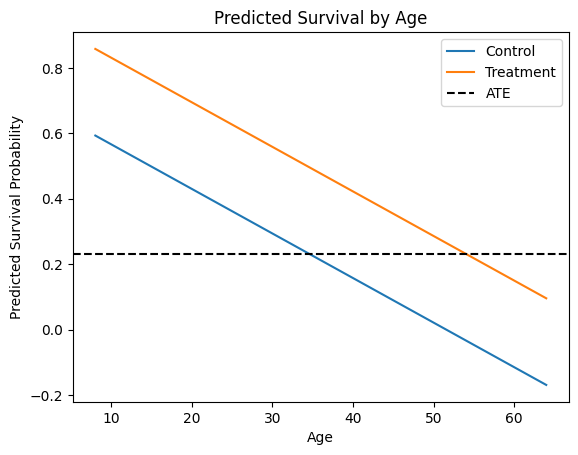

In [41]:
model_age = smf.ols("y ~ C(transplant) + age", data=df3).fit()
print(model_age.summary())
import numpy as np
age_range = np.linspace(df3["age"].min(), df3["age"].max(), 100)
pred_control = model_age.predict(pd.DataFrame({
    "age": age_range,
    "transplant": "control"
}))
pred_treatment = model_age.predict(pd.DataFrame({
    "age": age_range,
    "transplant": "treatment"
}))
plt.plot(age_range, pred_control, label="Control")
plt.plot(age_range, pred_treatment, label="Treatment")
plt.axhline(y=ate, linestyle="--", color="black", label="ATE")
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

3. The transplant coefficient increases from about 0.23 to 0.27 after controlling for age, showing that age was affecting the relationship. The intercept is the predicted survival for a control patient at age 0, and the age coefficient shows survival decreases with age. The ATE is constant, but it overestimates the impact at younger ages and underestimates it at older ages.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        18:57:06   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

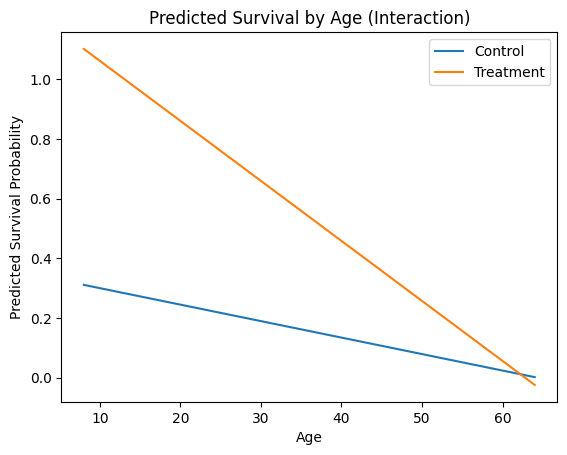

In [42]:
model_int = smf.ols("y ~ C(transplant) * age", data=df3).fit()
print(model_int.summary())
age_range = np.linspace(df3["age"].min(), df3["age"].max(), 100)
pred_control = model_int.predict(pd.DataFrame({
    "age": age_range,
    "transplant": "control"
}))
pred_treatment = model_int.predict(pd.DataFrame({
    "age": age_range,
    "transplant": "treatment"
}))
plt.plot(age_range, pred_control, label="Control")
plt.plot(age_range, pred_treatment, label="Treatment")
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age (Interaction)")
plt.legend()
plt.show()

4. With the interaction, the effect of transplant varies with age instead of being constant. The treatment group has higher survival at younger ages, but the benefit declines with age and eventually disappears, showing that the impact of transplant depends on age.

In [43]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import statsmodels.formula.api as smf
def cross_val_mse(formula, df, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    mses = []

    for train_idx, test_idx in kf.split(df):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        model = smf.ols(formula, data=train).fit()
        preds = model.predict(test)

        mse = mean_squared_error(test["y"], preds)
        mses.append(mse)

    return np.mean(mses)
mse1 = cross_val_mse("y ~ C(transplant)", df3)
mse2 = cross_val_mse("y ~ C(transplant) + age", df3)
mse3 = cross_val_mse("y ~ C(transplant) * age", df3)
print("Model 1:", mse1)
print("Model 2:", mse2)
print("Model 3:", mse3)

Model 1: 0.19497249586192153
Model 2: 0.17926415954952163
Model 3: 0.17880206762517423


5. Model 3 has the lowest MSE, but the improvement over Model 2 is very small. Adding age clearly improves the model, while the interaction adds only a slight benefit.

6. The model is too simple and misses important health factors, so it may give biased results. It also relies on observational data, which can introduce selection bias. Using it to prioritize transplants could unfairly disadvantage certain groups, especially older patients.